In [46]:
import numpy as np
from src.data_utils import MovieLensData
from src.model import MatrixFactorization
from src.analysis import (
    load_movie_titles,
    load_user_info,
    load_movies_with_genres,
    recommend_for_user,
    show_user_profile,
    show_recommendation_genres
)

In [47]:
movie_titles = load_movie_titles("data/u.item")
user_info = load_user_info("data/u.user")
movies_with_genres = load_movies_with_genres("data/u.item")

In [48]:
data = MovieLensData("data/u.data")

In [49]:
model = MatrixFactorization(
    data.n_users,
    data.n_items
)

In [50]:
print(model.user_emb.shape)
print(model.item_emb.shape)

(943, 64)
(1682, 64)


In [51]:
user_emb = model.user_emb
item_emb = model.item_emb

item_emb_norm = item_emb / np.linalg.norm(item_emb, axis=1, keepdims=True)

In [52]:


movie_titles = load_movie_titles("data/u.item")

In [53]:
print(movie_titles[0])

Toy Story (1995)


In [54]:
from src.train import train_infonce

train_infonce(model, data, epochs=25, lr=0.01, tau = 0.5)

Epoch 1, Loss: 1.6076
Epoch 2, Loss: 1.4380
Epoch 3, Loss: 1.0618
Epoch 4, Loss: 0.9374
Epoch 5, Loss: 0.8599
Epoch 6, Loss: 0.7654
Epoch 7, Loss: 0.6934
Epoch 8, Loss: 0.6521
Epoch 9, Loss: 0.6119
Epoch 10, Loss: 0.5757
Epoch 11, Loss: 0.5473
Epoch 12, Loss: 0.5163
Epoch 13, Loss: 0.4938
Epoch 14, Loss: 0.4700
Epoch 15, Loss: 0.4494
Epoch 16, Loss: 0.4260
Epoch 17, Loss: 0.4053
Epoch 18, Loss: 0.3853
Epoch 19, Loss: 0.3689
Epoch 20, Loss: 0.3458
Epoch 21, Loss: 0.3318
Epoch 22, Loss: 0.3152
Epoch 23, Loss: 0.2966
Epoch 24, Loss: 0.2817
Epoch 25, Loss: 0.2650


In [55]:
def similar_movies(movie_id, item_emb, movie_titles, k=10):

    emb = item_emb / np.linalg.norm(item_emb, axis=1, keepdims=True)

    query = emb[movie_id]

    scores = emb @ query

    scores[movie_id] = -np.inf

    top_k = np.argsort(scores)[-k:][::-1]

    print("Movie:", movie_titles[movie_id])
    print("\nSimilar movies:\n")

    for i in top_k:
        print(movie_titles[i])

In [56]:
similar_movies(49, item_emb, movie_titles)

Movie: Star Wars (1977)

Similar movies:

Return of the Jedi (1983)
Raiders of the Lost Ark (1981)
Toy Story (1995)
Empire Strikes Back, The (1980)
Fargo (1996)
Godfather, The (1972)
Twelve Monkeys (1995)
Indiana Jones and the Last Crusade (1989)
Star Trek: First Contact (1996)
Contact (1997)


In [57]:
user_id = 42

u = user_emb[user_id]

scores = item_emb_norm @ u

seen = data.train_history[user_id]

scores[list(seen)] = -np.inf

top_k = np.argsort(scores)[-10:][::-1]

print("Top recommendations:\n")

for i in top_k:
    print(movie_titles[i])

Top recommendations:

Harlem (1993)
Cure, The (1995)
The Courtyard (1995)
Mulholland Falls (1996)
Pretty Woman (1990)
Spitfire Grill, The (1996)
Children of the Revolution (1996)
Beverly Hills Cop III (1994)
Spanish Prisoner, The (1997)
Naked in New York (1994)


In [58]:
title_to_id = {title: idx for idx, title in movie_titles.items()}

In [59]:
def recommend_from_multiple_movies(movie_list, model, movie_titles, title_to_id, k=10):
    item_emb = model.item_emb
    emb = item_emb / np.linalg.norm(item_emb, axis=1, keepdims=True)
    movie_ids = [title_to_id[m] for m in movie_list]
    user_vec = emb[movie_ids].mean(axis=0)
    scores = emb @ user_vec
    scores[movie_ids] = -np.inf
    top_k = np.argsort(scores)[-k:][::-1]
    print("\nMovies you like:")
    for m in movie_list:
        print("-", m)
    print("\nRecommended movies:\n")
    for i in top_k:
        print(movie_titles[i])
    return top_k

In [60]:
recommend_from_multiple_movies(
    [
        "Star Wars (1977)",
        "Godfather, The (1972)",
        "Terminator, The (1984)"
    ],
    model,
    movie_titles,
    title_to_id
)


Movies you like:
- Star Wars (1977)
- Godfather, The (1972)
- Terminator, The (1984)

Recommended movies:

Return of the Jedi (1983)
Raiders of the Lost Ark (1981)
Empire Strikes Back, The (1980)
Terminator 2: Judgment Day (1991)
Indiana Jones and the Last Crusade (1989)
Alien (1979)
Silence of the Lambs, The (1991)
Fugitive, The (1993)
Fargo (1996)
Pulp Fiction (1994)


array([180, 173, 171,  95, 209, 182,  97,  78,  99,  55])

In [61]:

movies_with_genres = load_movies_with_genres("data/u.item")

In [62]:
from collections import Counter

def show_favorite_genres(movie_list, title_to_id, movies_with_genres):

    genre_counter = Counter()

    for m in movie_list:
        movie_id = title_to_id[m]
        genres = movies_with_genres[movie_id]["genres"]
        genre_counter.update(genres)

    print("\nZanrovi omiljenih filmova:")

    for genre, count in genre_counter.most_common():
        print(f"{genre}: {count}")

In [63]:
liked_movies = [
    "Star Wars (1977)",
        "Godfather, The (1972)",
        "Terminator, The (1984)"
]

show_favorite_genres(
    liked_movies,
    title_to_id,
    movies_with_genres
)

top_k = recommend_from_multiple_movies(
    liked_movies,
    model,
    movie_titles,
    title_to_id
)

show_recommendation_genres(
    top_k,
    movies_with_genres
)


Zanrovi omiljenih filmova:
Action: 3
Sci-Fi: 2
Adventure: 1
Romance: 1
War: 1
Crime: 1
Drama: 1
Thriller: 1

Movies you like:
- Star Wars (1977)
- Godfather, The (1972)
- Terminator, The (1984)

Recommended movies:

Return of the Jedi (1983)
Raiders of the Lost Ark (1981)
Empire Strikes Back, The (1980)
Terminator 2: Judgment Day (1991)
Indiana Jones and the Last Crusade (1989)
Alien (1979)
Silence of the Lambs, The (1991)
Fugitive, The (1993)
Fargo (1996)
Pulp Fiction (1994)

Žanrovi preporučenih filmova:
Action: 7
Thriller: 5
Adventure: 4
Sci-Fi: 4
Drama: 4
Romance: 2
War: 2
Crime: 2
Horror: 1


In [92]:
from sklearn.manifold import TSNE

tsne = TSNE(
    n_components=2,
    perplexity=40,
    learning_rate=200,
    init="pca",
    random_state=42
)

emb_2d = tsne.fit_transform(item_emb)

In [93]:
emb_2d.shape

(1682, 2)

In [94]:
import pandas as pd

In [95]:
highlight_movies = [
    "Star Wars (1977)",
        "Godfather, The (1972)",
        "Terminator, The (1984)",
        "Return of the Jedi (1983)",
    "Raiders of the Lost Ark (1981)",
    "Empire Strikes Back, The (1980)",
    "Indiana Jones and the Last Crusade (1989)",
    "Alien (1979)",
    "Silence of the Lambs, The (1991)"
]

In [96]:
highlight_ids = [title_to_id[m] for m in highlight_movies]

In [97]:
genres = []

for movie_id in range(len(item_emb)):
    g = movies_with_genres[movie_id]
    main_genre = g["genres"][0]
    
    genres.append(main_genre)

In [98]:
print(len(genres))

1682


In [99]:
genre_ids, genre_names = pd.factorize(genres)

/tmp/ipykernel_21587/3565612947.py:1: FutureWarning: factorize with argument that is not not a Series, Index, ExtensionArray, or np.ndarray is deprecated and will raise in a future version.
  genre_ids, genre_names = pd.factorize(genres)


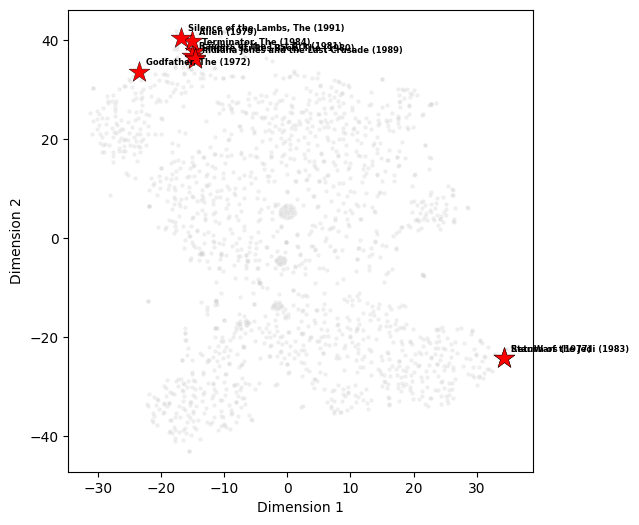

<Figure size 640x480 with 0 Axes>

In [108]:
from matplotlib import pyplot as plt
plt.figure(figsize=(6,6))
plt.scatter(
    emb_2d[:,0],
    emb_2d[:,1],
    s=5,
    color="lightgray",
    alpha=0.25
)

for movie, mid in zip(highlight_movies, highlight_ids):

    x = emb_2d[mid,0]
    y = emb_2d[mid,1]

    plt.scatter(
        x,
        y,
        s=250,
        marker="*",
        color="red",
        edgecolors="black",
        linewidth=0.3
    )

    plt.annotate(
        movie,
        (x, y),
        xytext=(5,5),
        textcoords="offset points",
        fontsize=6,
        weight="bold"
    )
plt.xlabel("Dimension 1")
plt.ylabel("Dimension 2")

plt.show()
plt.savefig("results/tsne")